In [9]:
import pandas as pd
df = pd.read_csv("data/clean_adjusted.csv")

In [ ]:
genre_cols = [c for c in df.columns if c.startswith("genre_")]

features = ["rating", "votes", "duration"] + genre_cols #get features

X = df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df[features].dropna() #drop the null values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #scale the data

## K Means Clustering

c:\Users\ishan\anaconda3\envs\surprise310\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


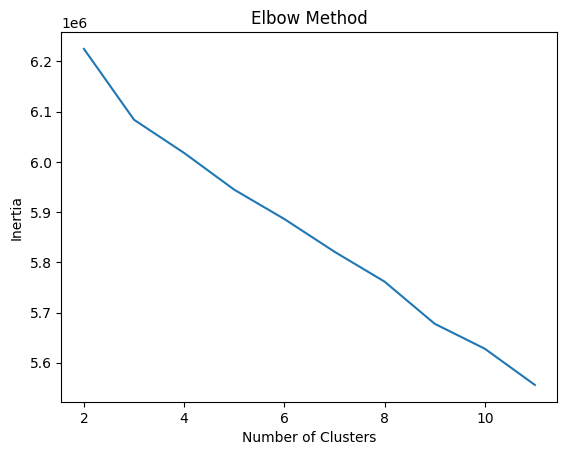

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 12):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

#plot inertia vs. number of clusters
plt.plot(range(2,12), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42) #fit k means

labels = kmeans.fit_predict(X_scaled) #predict on data

df_cluster = df.loc[X.index].copy()
df_cluster["cluster"] = labels #get the labels

<Axes: xlabel='votes', ylabel='rating'>

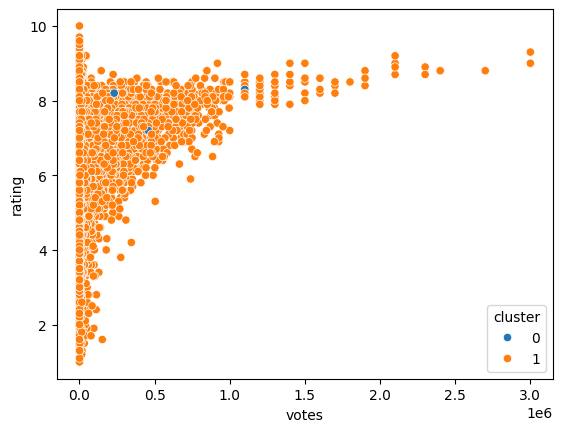

In [ ]:
#plot a scatterplot of the clusters
import seaborn as sns
sns.scatterplot(
    x="votes",
    y="rating",
    hue="cluster",
    data=df_cluster,
    palette="tab10"
)

In [18]:
df_cluster.groupby("cluster")[["rating","votes","duration"]].mean()

,rating,votes,duration
cluster,,,
0,6.761983,68668.677686,108.231405
1,6.145629,13572.233896,96.747297
2,6.560584,143371.979145,100.407716
3,6.696615,60916.247396,111.971354
4,5.585492,65894.751295,94.740933


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels) #get silhouette score of method 1

print(score)


0.46076478552232847


## K Means Clustering - Method 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv("data/clean_adjusted.csv")


Explained variance by 20 PCA components: 0.3314259927097792


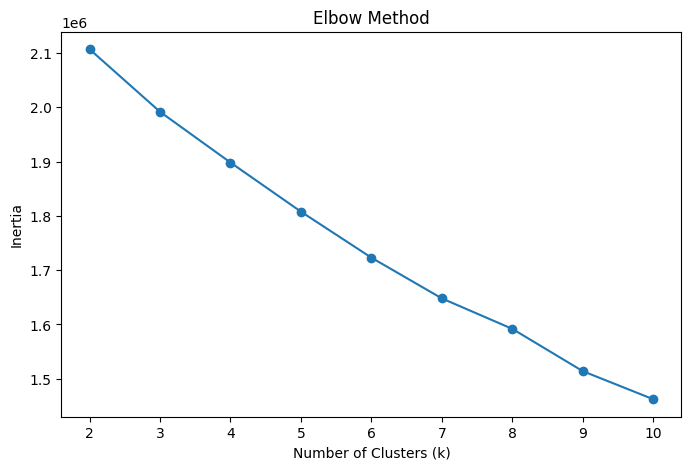

In [ ]:
df["log_votes"] = np.log1p(df["votes"]) #log the votes

# get all one-hot genre columns
genre_cols = [c for c in df.columns if c.startswith("genre_")]

# final feature list for clustering
features = ["rating", "duration", "log_votes"] + genre_cols

# keep only rows with needed data
X = df[features].copy()
X = X.fillna(0)

# keep aligned dataframe
df_cluster = df.loc[X.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# keep enough components to reduce noise but still preserve structure
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance by 20 PCA components:", pca.explained_variance_ratio_.sum())

inertia = []

#fit k means for multiple k
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

#plot inertia vs. k
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()



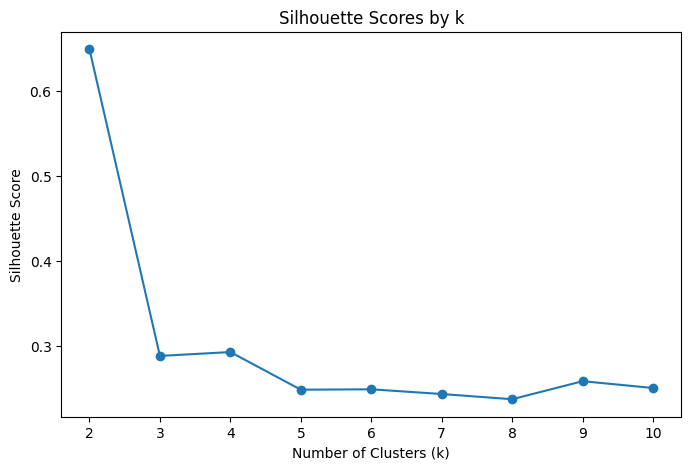

Silhouette scores:
k=2: 0.6490
k=3: 0.2882
k=4: 0.2928
k=5: 0.2485
k=6: 0.2490
k=7: 0.2434
k=8: 0.2373
k=9: 0.2585
k=10: 0.2505


In [ ]:
#get silhouette scores for multiple k
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    sil_scores.append(sil)

#plot silhouette scores vs k
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by k")
plt.show()

print("Silhouette scores:")
for k, score in zip(range(2, 11), sil_scores):
    print(f"k={k}: {score:.4f}")


In [ ]:
knn = NearestNeighbors(n_neighbors=6, metric="cosine") #cosine nearest neighbors with k = 6
knn.fit(X_pca)

df_knn = df_cluster.reset_index(drop=True)
X_knn = X_pca

#get similar movies function
def similar_movies(title, n=5):
    matches = df_knn[df_knn["title"].str.lower() == title.lower()] #get the specified movie
    
    if matches.empty:
        print(f"Movie '{title}' not found.")
        return None
    
    idx = matches.index[0]
    distances, indices = knn.kneighbors([X_knn[idx]], n_neighbors=n+1) #get neighbors
    
    result = df_knn.iloc[indices[0]].copy()
    result["distance"] = distances[0]
    
    # drop the movie itself
    result = result.iloc[1:]
    
    return result[["title", "rating", "votes", "cluster", "distance"]]

print(similar_movies("Toy Story", n=5)) #call for Toy Story

df_cluster.to_csv("data/clean_adjusted_with_clusters.csv", index=False)
print("\nSaved clustered dataset to data/clean_adjusted_with_clusters.csv")

                                   title  rating      votes  cluster  distance
61047                        Toy Story 4     7.6   295000.0        2  0.003308
49837                        Toy Story 3     8.3   926000.0        2  0.011666
31309  Cloudy with a Chance of Meatballs     6.9   270000.0        2  0.020342
2947                      Monsters, Inc.     8.1  1000000.0        2  0.032541
38056                        Toy Story 2     7.9   642000.0        2  0.043829

Saved clustered dataset to data/clean_adjusted_with_clusters.csv



Cluster counts:
cluster
0    11795
1    47404
2     1138
3     1442
4     1884
Name: count, dtype: int64

Cluster summary:
           rating          votes    duration
cluster                                     
0        6.054477   37932.031750  101.426037
1        6.173335    6327.921086   93.446714
2        6.641140   65926.488869   91.503100
3        7.014206  134536.722841  130.911744
4        5.668135   50438.828587   94.812834

Top genres by cluster:

Cluster 0 top genres:
genre_Thriller    0.626621
genre_Drama       0.588385
genre_Crime       0.554811
genre_Action      0.415939
genre_Mystery     0.295973
Name: 0, dtype: float64

Cluster 1 top genres:
genre_Drama        0.572293
genre_Comedy       0.343093
genre_Romance      0.254852
genre_Western      0.074825
genre_Adventure    0.074508
Name: 1, dtype: float64

Cluster 2 top genres:
genre_Animation    0.914763
genre_Adventure    0.727592
genre_Family       0.666081
genre_Fantasy      0.565905
genre_Comedy       0.540422
Name:

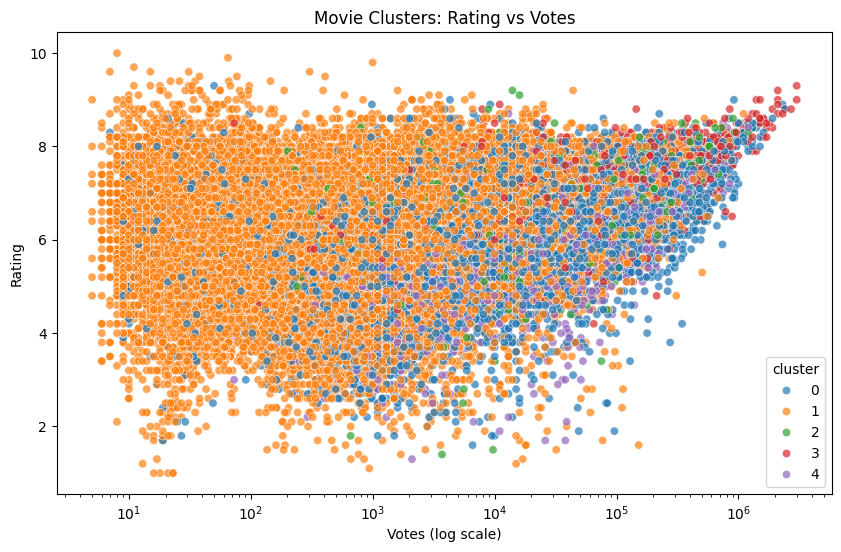

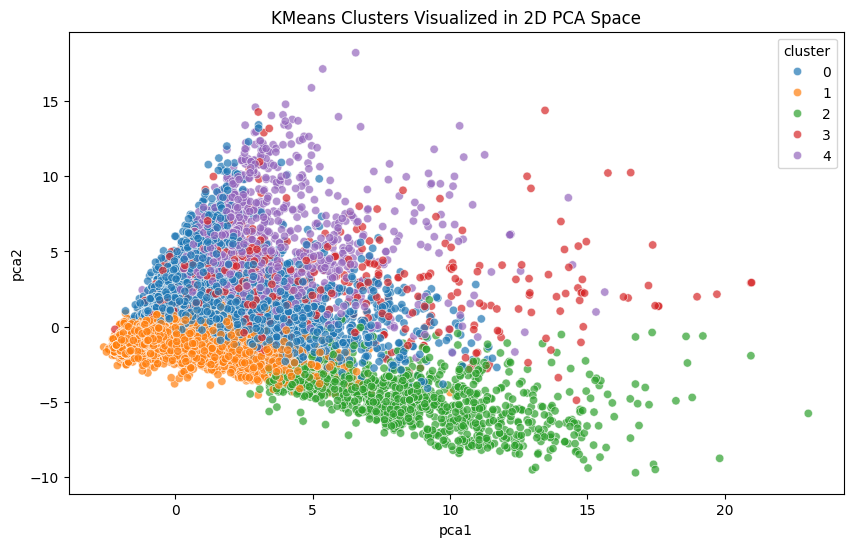

In [ ]:
final_k = 5 #set k =5

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

df_cluster["cluster"] = labels

#cluster metrics
print("\nCluster counts:")
print(df_cluster["cluster"].value_counts().sort_index())

print("\nCluster summary:")
print(df_cluster.groupby("cluster")[["rating", "votes", "duration"]].mean())

print("\nTop genres by cluster:")
genre_summary = df_cluster.groupby("cluster")[genre_cols].mean()

for c in sorted(df_cluster["cluster"].unique()):
    top_genres = genre_summary.loc[c].sort_values(ascending=False).head(5)
    print(f"\nCluster {c} top genres:")
    print(top_genres)

#plot rating vs. votes by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="votes",
    y="rating",
    hue="cluster",
    palette="tab10",
    alpha=0.7
)
plt.xscale("log")
plt.xlabel("Votes (log scale)")
plt.ylabel("Rating")
plt.title("Movie Clusters: Rating vs Votes")
plt.show()

#do PCA on the data
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

df_cluster["pca1"] = X_2d[:, 0]
df_cluster["pca2"] = X_2d[:, 1]

#plot the PCA data
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("KMeans Clusters Visualized in 2D PCA Space")
plt.show()

In [ ]:
print(similar_movies("Zero Dark Thirty", n=5)) #get similar movies for Zero Dark Thirty

                                    title  rating     votes  cluster  distance
24480                       Thirteen Days     7.3   65000.0        3  0.011716
42137  Bonhoeffer: Pastor. Spy. Assassin.     6.3    3400.0        3  0.020987
51095                                Argo     7.7  651000.0        3  0.021451
24768                     Bridge of Spies     7.6  335000.0        3  0.022380
43642                                 JFK     8.0  176000.0        3  0.022467


## Hierarchical clustering

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("data/clean_adjusted.csv")

df["log_votes"] = np.log1p(df["votes"])

genre_cols = [c for c in df.columns if c.startswith("genre_")]

features = ["normalized_score", "duration", "log_votes"] + genre_cols

X = df[features].fillna(0)

# keep aligned dataframe
df_cluster = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_.sum()) #get explained variance from PCA



Explained variance: 0.3313185316725973


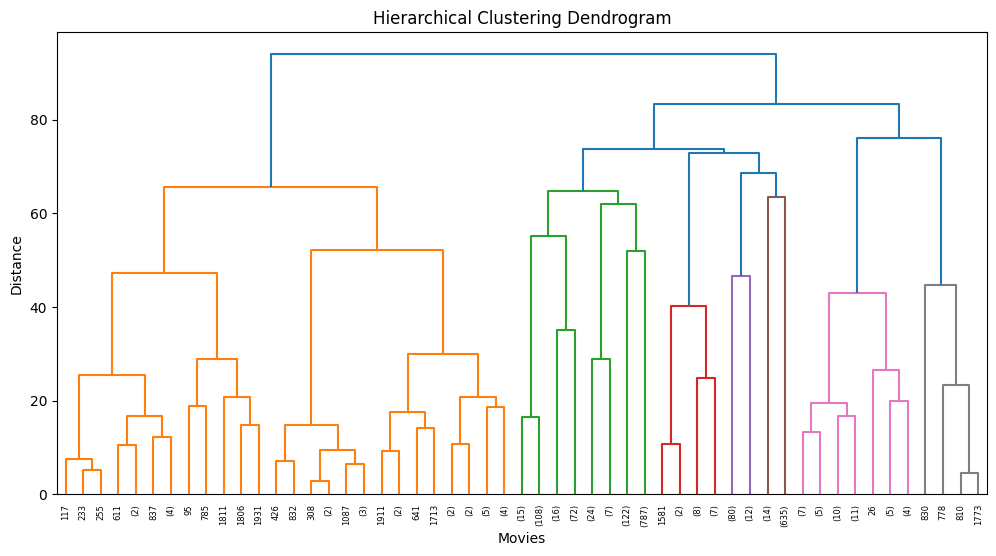

In [ ]:
sample_size = 2000
X_sample = X_pca[np.random.choice(X_pca.shape[0], sample_size, replace=False)] #get a sample of the data

linked = linkage(X_sample, method="ward") #use ward linkage

#plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()



In [17]:
# Agglomerative Clustering
n_clusters = 5

agg = AgglomerativeClustering(n_clusters=n_clusters)

labels = agg.fit_predict(X_pca)

df_cluster["hier_cluster"] = labels

print("\nCluster counts:")
print(df_cluster["hier_cluster"].value_counts())

print("\nCluster averages:")
print(df_cluster.groupby("hier_cluster")[["rating","votes","duration"]].mean())



Cluster counts:
hier_cluster
0    58577
2     2329
1     1340
4      824
3      593
Name: count, dtype: int64

Cluster averages:
                rating          votes    duration
hier_cluster                                     
0             6.164658   11782.356351   95.513997
1             6.545365   90387.469480   97.100525
2             5.794801   53105.089688   96.258204
3             6.565144   68438.807107  102.908784
4             6.195466  190936.322304  110.717949



Cluster 0 top genres:
genre_Drama       0.581850
genre_Comedy      0.303925
genre_Romance     0.233453
genre_Crime       0.153285
genre_Thriller    0.134507
Name: 0, dtype: float64

Cluster 1 top genres:
genre_Adventure    0.638060
genre_Animation    0.632836
genre_Fantasy      0.627612
genre_Family       0.521642
genre_Comedy       0.473134
Name: 1, dtype: float64

Cluster 2 top genres:
genre_Horror            0.707600
genre_Thriller          0.638471
genre_Mystery           0.428510
genre_Drama             0.377845
genre_Slasher Horror    0.262344
Name: 2, dtype: float64

Cluster 3 top genres:
genre_Drama            0.762226
genre_Coming-of-Age    0.583474
genre_Comedy           0.526138
genre_Romance          0.419899
genre_Teen Drama       0.354132
Name: 3, dtype: float64

Cluster 4 top genres:
genre_Sci-Fi       0.736650
genre_Action       0.501214
genre_Adventure    0.446602
genre_Thriller     0.337379
genre_Drama        0.331311
Name: 4, dtype: float64


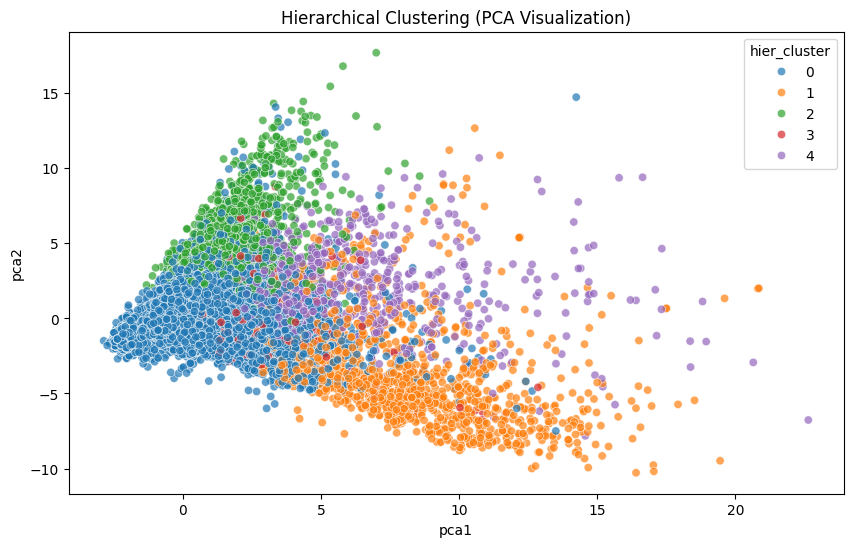

In [ ]:
# Top genres per cluster
genre_summary = df_cluster.groupby("hier_cluster")[genre_cols].mean()

#get top genres per cluster
for c in sorted(df_cluster["hier_cluster"].unique()):
    
    print(f"\nCluster {c} top genres:")
    
    print(
        genre_summary.loc[c]
        .sort_values(ascending=False)
        .head(5)
    )

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

df_cluster["pca1"] = X_2d[:,0]
df_cluster["pca2"] = X_2d[:,1]

plt.figure(figsize=(10,6))

#plot pca with hierarchical clustering
sns.scatterplot(
    data=df_cluster,
    x="pca1",
    y="pca2",
    hue="hier_cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("Hierarchical Clustering (PCA Visualization)")
plt.show()

# Save results
df_cluster.to_csv("data/hierarchical_clusters.csv", index=False)

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

# reset index so row positions match X_pca
df_search = df_cluster.reset_index(drop=True)

#get closes movies in PCA space
def closest_movies(title, n=5):
    matches = df_search[df_search["title"].str.lower() == title.lower()]
    
    if matches.empty:
        print(f"{title} not found")
        return
    
    idx = matches.index[0]
    
    # compute distance from this one movie to all others
    distances = euclidean_distances(X_pca[idx].reshape(1, -1), X_pca).flatten()
    
    nearest_idx = distances.argsort()[1:n+1]
    
    result = df_search.iloc[nearest_idx][["title", "rating", "votes", "hier_cluster"]].copy()
    result["distance"] = distances[nearest_idx]
    
    return result

In [ ]:
closest_movies("Toy Story") #call function on Toy Story

,title,rating,votes,hier_cluster,distance
61047,Toy Story 4,7.6,295000.0,1,2.225240
49837,Toy Story 3,8.3,926000.0,1,3.884006
31309,Cloudy with a Chance of Meatballs,6.9,270000.0,1,4.991217
2947,"Monsters, Inc.",8.1,1000000.0,4,6.347987
38056,Toy Story 2,7.9,642000.0,1,7.200341


In [ ]:
closest_movies("Zero Dark Thirty") #call function on Zero Dark Thirty

,title,rating,votes,hier_cluster,distance
24480,Thirteen Days,7.3,65000.0,0,3.784115
43642,JFK,8.0,176000.0,0,4.651014
51095,Argo,7.7,651000.0,0,5.604648
1493,The Post,7.2,167000.0,0,6.248701
13428,Breach,7.0,63000.0,0,6.933643
